## Project Description
In this project, you will analyze pharmaceutical sales data. Analysing sales data based on historical data is a very common data analysis task. This is a great way to start working with data science projects.



In [13]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv(r'data\salesdaily.csv')

In [15]:
def analyze_dataset(data):
    """
    Prints a high-level overview, structure, and summary statistics of a DataFrame.
    """
    print("--- FIRST 5 ROWS ---")
    print(data.head())
    
    print("\n--- DATASET INFORMATION ---")
    data.info()
    
    print("\n--- STATISTICAL SUMMARY ---")
    print(data.describe())

analyze_dataset(df)


--- FIRST 5 ROWS ---
      datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03  R06  Year  Month  \
0  1/2/2014    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1  1/3/2014    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2  1/4/2014    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3  1/5/2014    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4  1/6/2014    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   Hour Weekday Name  
0   248     Thursday  
1   276       Friday  
2   276     Saturday  
3   276       Sunday  
4   276       Monday  

--- DATASET INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA     

In [16]:
df['datum'] = pd.to_datetime(df['datum'])

In [17]:
analyze_dataset(df)

--- FIRST 5 ROWS ---
       datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03  R06  Year  Month  \
0 2014-01-02    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1 2014-01-03    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2 2014-01-04    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3 2014-01-05    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4 2014-01-06    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   Hour Weekday Name  
0   248     Thursday  
1   276       Friday  
2   276     Saturday  
3   276       Sunday  
4   276       Monday  

--- DATASET INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[ns]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 

In [18]:
def check_invalid_values(data):
    print("Sum of Null values: ")
    print(data.isnull().sum())

    print("Sum of duplicate values: ")
    print(data.duplicated().sum())

check_invalid_values(df)

Sum of Null values: 
datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64
Sum of duplicate values: 
0


# Answer the following questions using Pandas and Matplotlib:

1.What are the total sales quantities for each drug category (ATC code)?

2.Which individual drug brands have the highest total sales?

3.Which three drugs have the highest sales in January 2015, July 2016, September 2017?

4.Which drug has sold the most often in 2017?

5.Which drug category has the highest average daily sales?

6.Are respiratory drugs (R03) sold more during specific months?



C:\Users\Asus\AppData\Local\Temp\ipykernel_6232\1616003764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = total_sales.index, y = total_sales.values, palette = 'Blues_d')


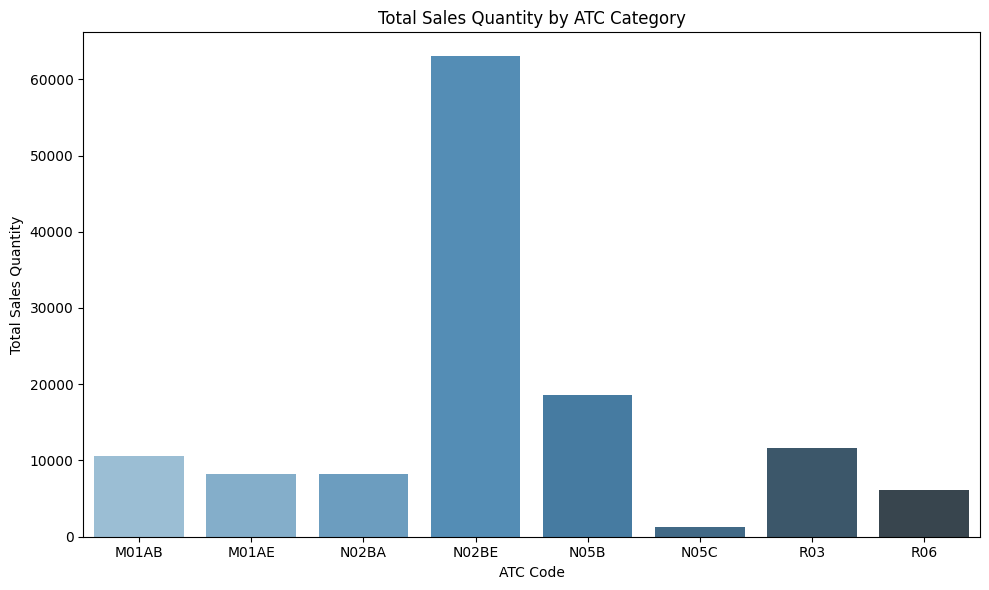

In [19]:
# What are the total sales quantities for each drug category (ATC code)?
ATC = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
total_sales = df[ATC].sum()

plt.figure(figsize = (10, 6))
sns.barplot(x = total_sales.index, y = total_sales.values, palette = 'Blues_d')


plt.title('Total Sales Quantity by ATC Category')
plt.xlabel('ATC Code')
plt.ylabel('Total Sales Quantity')
plt.tight_layout()
plt.show()


#### N02BE has the highest total sales quality for each drug category

C:\Users\Asus\AppData\Local\Temp\ipykernel_6232\4001989655.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = total_sales1, x = 'ATC_code', y = 'Total_sales', palette = 'Blues_r')


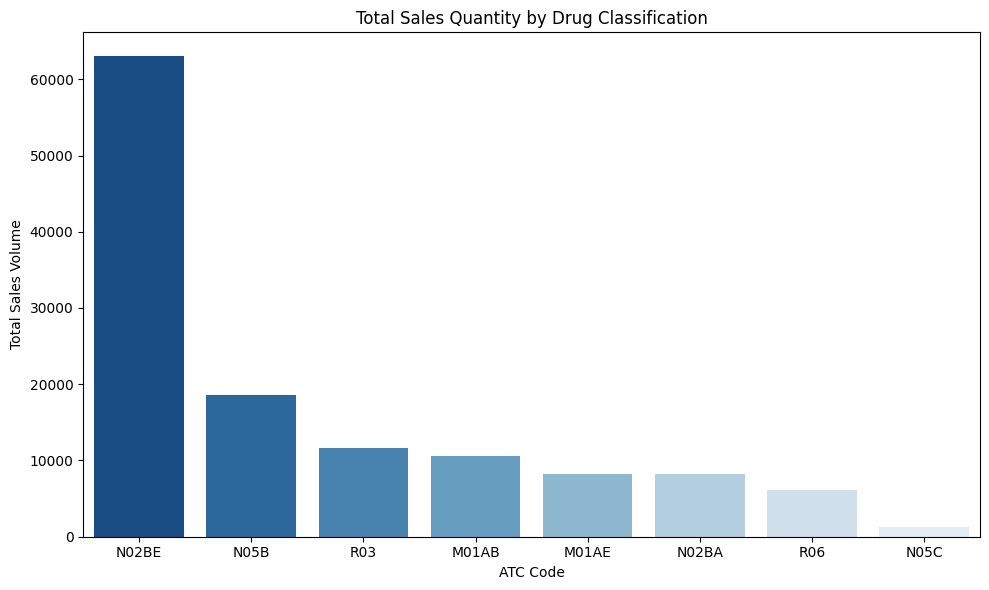

In [20]:
# Which individual drug brands have the highest total sales?
total_sales1 = df[ATC].sum().reset_index()
total_sales1.columns = ['ATC_code', 'Total_sales']

total_sales1 = total_sales1.sort_values(by = 'Total_sales', ascending = False)

plt.figure(figsize = (10, 6))
sns.barplot(data = total_sales1, x = 'ATC_code', y = 'Total_sales', palette = 'Blues_r')

plt.title('Total Sales Quantity by Drug Classification')
plt.xlabel('ATC Code')
plt.ylabel('Total Sales Volume')
plt.tight_layout()
plt.show()

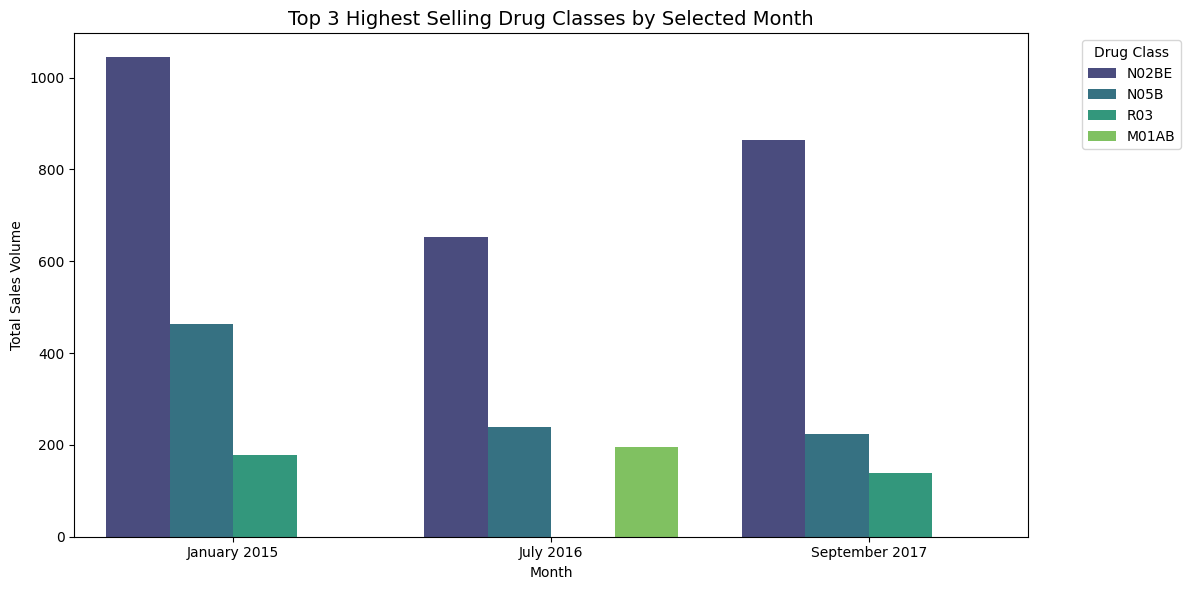

In [21]:
# Which three drugs have the highest sales in January 2015, July 2016, September 2017?
df.set_index('datum', inplace = True)

target_months = {
    'January 2015': '2015-01',
    'July 2016': '2016-07',
    'September 2017': '2017-09'
}

plot_data = []

for month_name, date_string in target_months.items():
    month_totals = df.loc[date_string, ATC].sum()

    top_three = month_totals.nlargest(3)

    for drug, sales, in top_three.items():
        plot_data.append({'Month': month_name, 'Drug Class': drug, 'Total Sales': sales})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize = (12, 6))

sns.barplot(data = plot_df, x = 'Month', y = 'Total Sales', hue = 'Drug Class', palette = 'viridis')

plt.title('Top 3 Highest Selling Drug Classes by Selected Month', fontsize=14)
plt.ylabel('Total Sales Volume')
plt.xlabel('Month')
plt.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2106 entries, 2014-01-02 to 2019-10-08
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   M01AB         2106 non-null   float64
 1   M01AE         2106 non-null   float64
 2   N02BA         2106 non-null   float64
 3   N02BE         2106 non-null   float64
 4   N05B          2106 non-null   float64
 5   N05C          2106 non-null   float64
 6   R03           2106 non-null   float64
 7   R06           2106 non-null   float64
 8   Year          2106 non-null   int64  
 9   Month         2106 non-null   int64  
 10  Hour          2106 non-null   int64  
 11  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(1)
memory usage: 213.9+ KB


In [24]:
# Which drug has sold the most often in 2017?

df_2017 = (df[df['Year'] == 2017])

sales_2017 = df_2017[ATC].sum()
top_drug = sales_2017.idxmax()
top_sales_value = sales_2017.max()
print(f"The drug that sold the most in 2017 is {top_drug} with {top_sales_value} units.")

The drug that sold the most in 2017 is N02BE with 9258.80483333 units.


C:\Users\Asus\AppData\Local\Temp\ipykernel_6232\1527372798.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_2017_sorted.values, y=sales_2017_sorted.index, palette='Blues_r')


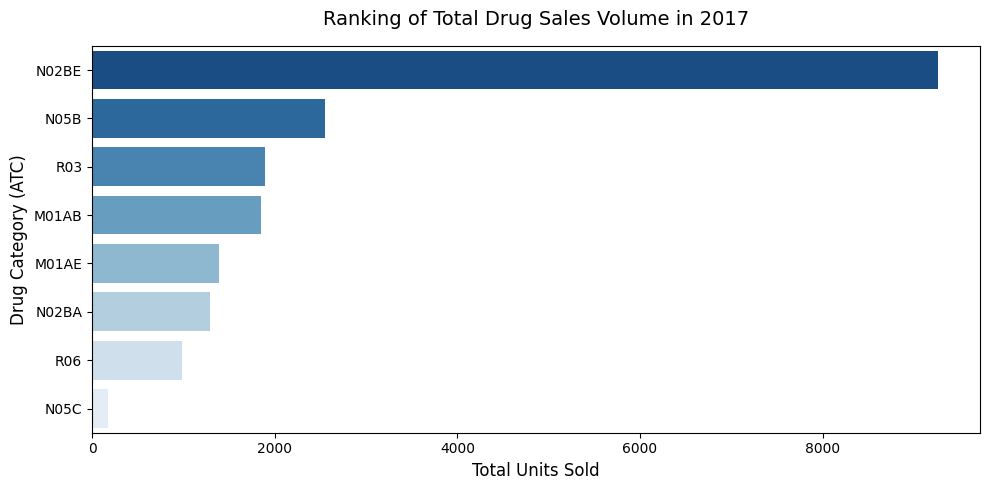

In [25]:
# Sort sales from highest to lowest for clean visual ranking
sales_2017_sorted = sales_2017.sort_values(ascending=False)

# Plot the ranking
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_2017_sorted.values, y=sales_2017_sorted.index, palette='Blues_r')

plt.title('Ranking of Total Drug Sales Volume in 2017', fontsize=14, pad=15)
plt.xlabel('Total Units Sold', fontsize=12)
plt.ylabel('Drug Category (ATC)', fontsize=12)
plt.tight_layout()
plt.show()


In [29]:
# Which drug category has the highest average daily sales?
average_sale = df[ATC].mean().sort_values(ascending = False)

In [30]:
average_sale

N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64

C:\Users\Asus\AppData\Local\Temp\ipykernel_6232\1781856307.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_sale.values, y=average_sale.index, palette='rocket')


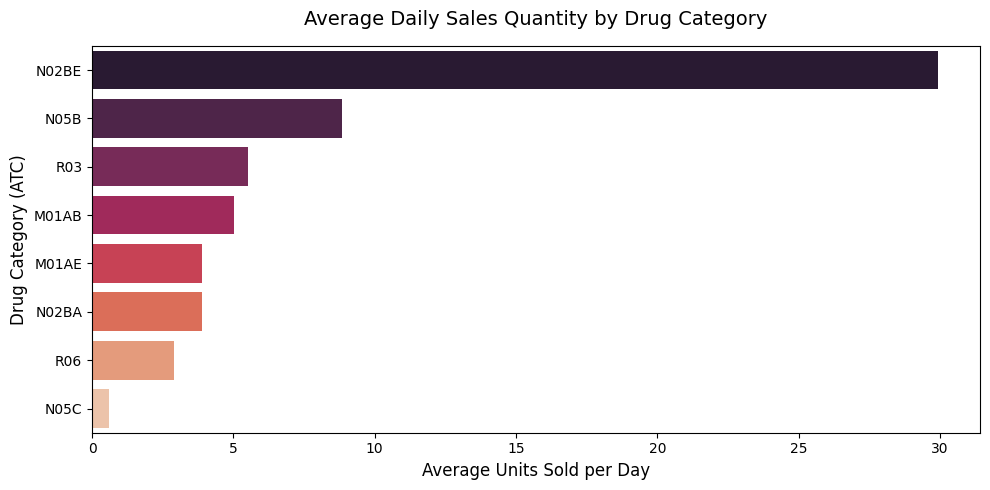

In [31]:
plt.figure(figsize=(10, 5))
# Use 'rocket' palette to dynamically shade the highest values darker
sns.barplot(x=average_sale.values, y=average_sale.index, palette='rocket')

plt.title('Average Daily Sales Quantity by Drug Category', fontsize=14, pad=15)
plt.xlabel('Average Units Sold per Day', fontsize=12)
plt.ylabel('Drug Category (ATC)', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
df.to_csv("cleaned_data.csv")

In [36]:
df.rename(columns={
    "datum": "Date",
    "M01AB": "AntiInflammatory_Derivatives_Sales",
    "M01AE": "PropionicAcid_Derivatives_Sales",
    "N02BA": "SalicylicAcid_Analgesics_Sales",
    "N02BE": "Anilide_Analgesics_Sales",
    "N05B": "Anxiolytics_Sales",
    "N05C": "Hypnotics_Sedatives_Sales",
    "R03": "AntiAsthma_COPD_Sales",
    "R06": "Antihistamines_Sales",
    "Weekday Name": "Weekday"
}, inplace=True) 